# Pharma Data ETL Pipeline: From Raw Reviews to a Queryable Data Warehouse

**Author:** Aritra Pal

## 📌 Executive Summary
This notebook builds a small but complete **ETL (Extract, Transform, Load) pipeline** on top of the
UCI ML Drug Review dataset (the same dataset used in my earlier NLP sentiment analysis project).

Instead of treating the data as a single flat file for analysis, this project treats it like a real
data engineering problem:

- **Extract** raw review-level data and split it into two logical sources (a drug *master* table and a
  review *transaction* table), the way this data would realistically arrive from separate systems.
- **Transform** the data: clean text, standardize inconsistent drug naming, engineer new features
  (sentiment score, review length, usefulness ratio), and reshape it into a simple **star schema**
  (one fact table + one dimension table).
- **Load** the modeled tables into a local **SQLite** database so the data is queryable with SQL,
  not just sitting in a dataframe.
- **Query & Visualize** the warehouse to answer real business questions.

## 🛠️ Tech Stack
- **Language:** Python
- **Data Manipulation:** Pandas, NumPy
- **NLP:** NLTK (VADER Sentiment Intensity Analyzer)
- **Data Modeling / Warehousing:** SQLite (via Python's built-in `sqlite3`)
- **Visualization:** Matplotlib, Seaborn

## 📂 Dataset
- **Source:** UCI ML Drug Review Dataset (`drugsComTrain_raw.csv`)
- On Kaggle, this is commonly available as the dataset **"UCI ML Drugs Dataset"**.
- If you're running this in a Kaggle Notebook, add that dataset via **"+ Add Input"** on the right
  sidebar, then check the exact path in `/kaggle/input/` (see the path-check cell below) and update
  `RAW_PATH` accordingly.


## 1. Setup & Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Database (our lightweight "data warehouse")
import sqlite3

# NLP sentiment scoring
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import re
import os

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Locate the Dataset (Kaggle-friendly path check)

In [2]:
# On Kaggle, input datasets live under /kaggle/input/<dataset-name>/<file>.csv
# This cell just lists what's available so you can copy the exact path if it
# differs from the default guess below. Safe to run even if paths don't match yet.

kaggle_input_root = "/kaggle/input"

if os.path.exists(kaggle_input_root):
    for root, dirs, files in os.walk(kaggle_input_root):
        for f in files:
            print(os.path.join(root, f))
else:
    print("Not running on Kaggle (or no input mounted yet). "
          "Set RAW_PATH manually in the next cell to your local CSV path.")


/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTest_raw.csv
/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv


In [3]:
# --- EDIT THIS PATH if your dataset folder name differs from the guess below ---
RAW_PATH = "/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv"

# Fallback for local/non-Kaggle runs (edit as needed)
 # place file in the same folder as this notebook

print(f"Using RAW_PATH: {RAW_PATH}")


Using RAW_PATH: /kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv


## 3. EXTRACT — Load Raw Data & Split into Two Logical Sources

Real-world pipelines rarely start from one clean file. Here, we simulate that by splitting the raw
review data into:

1. **`raw_drug_master`** — one row per unique `(drugName, condition)` pair. This mimics a
   *master/reference* data source (like a product catalog system).
2. **`raw_reviews`** — the individual review/transaction records, referencing the drug by name.

This split is exactly why the later "Transform" step needs to reconcile the two back together —
which is the core skill behind ETL and data modeling.


In [4]:
# Load the raw flat file
raw = pd.read_csv(RAW_PATH)

print(f"Raw shape: {raw.shape}")
raw.head()


Raw shape: (161297, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [5]:
# --- Source 1: Drug Master data (simulating a reference/catalog system) ---
raw_drug_master = (
    raw[['drugName', 'condition']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Extracted {len(raw_drug_master)} unique drug-condition combinations for the master table.")
raw_drug_master.head()


Extracted 8490 unique drug-condition combinations for the master table.


,drugName,condition
0,Valsartan,Left Ventricular Dysfunction
1,Guanfacine,ADHD
2,Lybrel,Birth Control
3,Ortho Evra,Birth Control
4,Buprenorphine / naloxone,Opiate Dependence


In [6]:
# --- Source 2: Review/Transaction data (simulating a transactional review-capture system) ---
raw_reviews = raw[['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']].copy()

print(f"Extracted {len(raw_reviews)} raw review transactions.")
raw_reviews.head()


Extracted 161297 raw review transactions.


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


## 4. TRANSFORM — Clean, Standardize, Engineer Features, and Model as a Star Schema

This is the core of the pipeline. Steps:

1. **Clean text** — strip HTML artifacts, normalize whitespace/casing (reused approach from the
   sentiment analysis project).
2. **Standardize drug names** — trim whitespace and fix casing inconsistencies so the same drug
   isn't treated as multiple different entities.
3. **Handle missing values** in the condition field.
4. **Engineer new features**:
   - `sentiment_score` — VADER compound sentiment on the review text.
   - `review_length` — word count of the review (proxy for review depth/detail).
   - `usefulness_ratio` — usefulCount normalized by review length (a lightweight "was this a
     high-value review" signal).
5. **Model as a star schema**:
   - `dim_drug` (dimension table): one row per drug-condition, with a surrogate key `drug_id`.
   - `fact_reviews` (fact table): one row per review, linked to `dim_drug` via `drug_id`.


In [7]:
def clean_text(text: str) -> str:
    """Basic clinical text cleaning: decode HTML entities, strip non-alpha
    characters, normalize whitespace, and lowercase for consistency."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("&#039;", "'").replace("&quot;", '"').replace("&amp;", "&")
    text = re.sub(r'[^a-zA-Z0-9\s\.,!?\'"-]', ' ', text)   # strip stray symbols
    text = re.sub(r'\s+', ' ', text).strip()                # collapse whitespace
    return text

def standardize_drug_name(name: str) -> str:
    """Trim whitespace and standardize casing so the same drug isn't
    accidentally split into multiple master records."""
    if pd.isna(name):
        return "Unknown"
    return str(name).strip().title()

print("Cleaning functions defined.")


Cleaning functions defined.


In [8]:
# --- Apply cleaning & standardization ---

# Clean drug master
raw_drug_master['drugName'] = raw_drug_master['drugName'].apply(standardize_drug_name)
raw_drug_master['condition'] = raw_drug_master['condition'].fillna("Unknown Condition")
raw_drug_master = raw_drug_master.drop_duplicates().reset_index(drop=True)

# Clean reviews
raw_reviews['drugName'] = raw_reviews['drugName'].apply(standardize_drug_name)
raw_reviews['condition'] = raw_reviews['condition'].fillna("Unknown Condition")
raw_reviews['review_clean'] = raw_reviews['review'].apply(clean_text)
raw_reviews['date'] = pd.to_datetime(raw_reviews['date'], errors='coerce')

print("Cleaning complete.")
raw_reviews[['drugName', 'condition', 'review_clean']].head()


/tmp/ipykernel_16/2098661940.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_reviews['date'] = pd.to_datetime(raw_reviews['date'], errors='coerce')


Cleaning complete.


,drugName,condition,review_clean
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati..."
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ..."
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh..."
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth..."
4,Buprenorphine / Naloxone,Opiate Dependence,"""Suboxone has completely turned my life around..."


In [9]:
# --- Feature Engineering ---

sia = SentimentIntensityAnalyzer()

# 1. Sentiment score (VADER compound score, range -1 to +1)
raw_reviews['sentiment_score'] = raw_reviews['review_clean'].apply(
    lambda t: sia.polarity_scores(t)['compound']
)

# 2. Review length (word count)
raw_reviews['review_length'] = raw_reviews['review_clean'].apply(lambda t: len(t.split()))

# 3. Usefulness ratio (guard against divide-by-zero for empty reviews)
raw_reviews['usefulness_ratio'] = raw_reviews.apply(
    lambda row: row['usefulCount'] / row['review_length'] if row['review_length'] > 0 else 0,
    axis=1
)

print("Feature engineering complete.")
raw_reviews[['drugName', 'sentiment_score', 'review_length', 'usefulness_ratio']].head()


Feature engineering complete.


,drugName,sentiment_score,review_length,usefulness_ratio
0,Valsartan,-0.2960,17,1.588235
1,Guanfacine,0.8598,142,1.352113
2,Lybrel,0.7962,134,0.126866
3,Ortho Evra,0.7184,89,0.112360
4,Buprenorphine / Naloxone,0.9403,124,0.298387


In [10]:
# --- Build the Star Schema ---

# dim_drug: one row per unique drug-condition, with a surrogate key
dim_drug = raw_drug_master.copy()
dim_drug.insert(0, 'drug_id', range(1, len(dim_drug) + 1))

# Create a lookup to map (drugName, condition) -> drug_id
drug_key_lookup = dim_drug.set_index(['drugName', 'condition'])['drug_id']

# fact_reviews: link each review back to its drug_id via the lookup
fact_reviews = raw_reviews.copy()
fact_reviews['drug_id'] = fact_reviews.apply(
    lambda row: drug_key_lookup.get((row['drugName'], row['condition']), np.nan),
    axis=1
)

# Drop any reviews that failed to map (data quality safeguard) and keep only fact columns
fact_reviews = fact_reviews.dropna(subset=['drug_id'])
fact_reviews['drug_id'] = fact_reviews['drug_id'].astype(int)

fact_reviews = fact_reviews[[
    'uniqueID', 'drug_id', 'rating', 'sentiment_score',
    'review_length', 'usefulness_ratio', 'usefulCount', 'date'
]].rename(columns={'uniqueID': 'review_id'})

print(f"dim_drug: {dim_drug.shape}")
print(f"fact_reviews: {fact_reviews.shape}")
dim_drug.head()


dim_drug: (8490, 3)
fact_reviews: (160398, 8)


,drug_id,drugName,condition
0,1,Valsartan,Left Ventricular Dysfunction
1,2,Guanfacine,ADHD
2,3,Lybrel,Birth Control
3,4,Ortho Evra,Birth Control
4,5,Buprenorphine / Naloxone,Opiate Dependence


In [11]:
fact_reviews.head()

,review_id,drug_id,rating,sentiment_score,review_length,usefulness_ratio,usefulCount,date
0,206461,1,9,-0.2960,17,1.588235,27,2012-05-20
1,95260,2,8,0.8598,142,1.352113,192,2010-04-27
2,92703,3,5,0.7962,134,0.126866,17,2009-12-14
3,138000,4,8,0.7184,89,0.112360,10,2015-11-03
4,35696,5,9,0.9403,124,0.298387,37,2016-11-27


## 5. LOAD — Write the Modeled Tables into a SQLite Data Warehouse

This is what separates a "notebook analysis" from an actual ETL pipeline: the transformed,
modeled data gets persisted into a real, queryable database rather than staying in memory as
dataframes.


In [12]:
DB_PATH = "pharma_reviews_warehouse.db"

# Fresh connection each run (overwrite tables if they already exist)
conn = sqlite3.connect(DB_PATH)

dim_drug.to_sql('dim_drug', conn, if_exists='replace', index=False)
fact_reviews.to_sql('fact_reviews', conn, if_exists='replace', index=False)

conn.commit()
print(f"Loaded 'dim_drug' and 'fact_reviews' into {DB_PATH}")


Loaded 'dim_drug' and 'fact_reviews' into pharma_reviews_warehouse.db


## 6. Query the Warehouse — Answering Real Business Questions with SQL

Now that the data lives in SQLite, we can query it with plain SQL instead of pandas filtering —
this is the payoff of building a proper warehouse layer.


In [13]:
# Q1: Which medical conditions have the lowest average sentiment
# (i.e. hidden side-effect burden not captured by star ratings alone)?

query_1 = """
SELECT
    d.condition,
    COUNT(*) AS review_count,
    ROUND(AVG(f.sentiment_score), 3) AS avg_sentiment,
    ROUND(AVG(f.rating), 2) AS avg_rating
FROM fact_reviews f
JOIN dim_drug d ON f.drug_id = d.drug_id
GROUP BY d.condition
HAVING review_count >= 50
ORDER BY avg_sentiment ASC
LIMIT 10;
"""

lowest_sentiment_conditions = pd.read_sql_query(query_1, conn)
lowest_sentiment_conditions


,condition,review_count,avg_sentiment,avg_rating
0,Dental Abscess,90,-0.470,6.50
1,Neuropathic Pain,253,-0.434,6.42
2,Postherpetic Neuralgia,71,-0.422,7.30
3,Diverticulitis,142,-0.388,6.68
4,Osteoporosis,372,-0.374,4.83
5,Inflammatory Conditions,303,-0.358,7.16
6,Kidney Infections,117,-0.358,5.58
7,Breast Cance,272,-0.352,5.68
8,Diabetic Peripheral Neuropathy,175,-0.325,6.55
9,Trigeminal Neuralgia,162,-0.322,7.51


/tmp/ipykernel_16/3332645126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


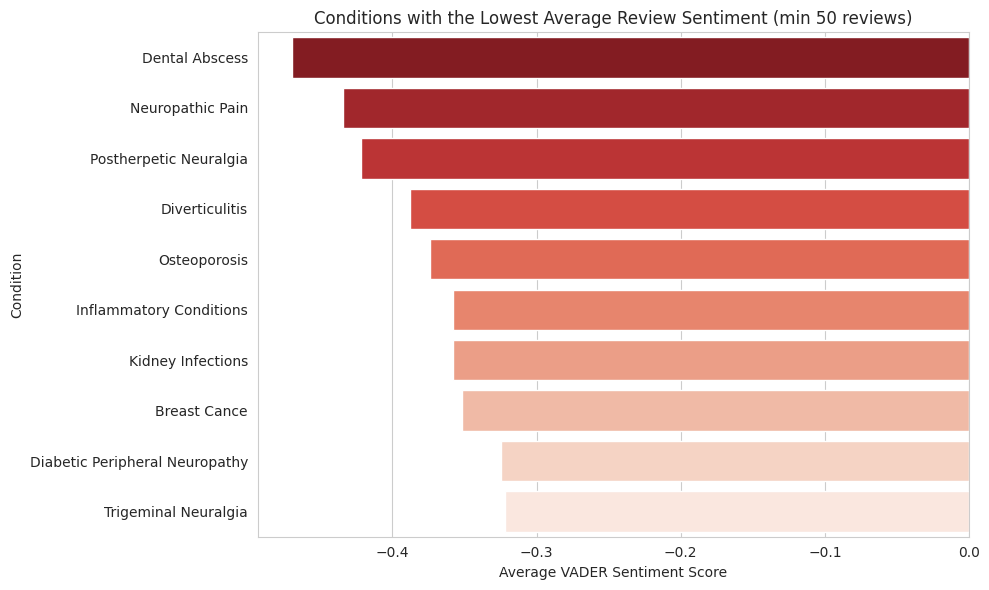

In [14]:
# Visualize Q1
plt.figure(figsize=(10, 6))
sns.barplot(
    data=lowest_sentiment_conditions,
    x='avg_sentiment', y='condition', palette='Reds_r'
)
plt.title('Conditions with the Lowest Average Review Sentiment (min 50 reviews)')
plt.xlabel('Average VADER Sentiment Score')
plt.ylabel('Condition')
plt.tight_layout()
plt.show()


In [15]:
# Q2: Which drugs get the most review volume, and how does their sentiment compare?

query_2 = """
SELECT
    d.drugName,
    COUNT(*) AS review_count,
    ROUND(AVG(f.sentiment_score), 3) AS avg_sentiment,
    ROUND(AVG(f.rating), 2) AS avg_rating
FROM fact_reviews f
JOIN dim_drug d ON f.drug_id = d.drug_id
GROUP BY d.drugName
ORDER BY review_count DESC
LIMIT 10;
"""

top_drugs_by_volume = pd.read_sql_query(query_2, conn)
top_drugs_by_volume


,drugName,review_count,avg_sentiment,avg_rating
0,Levonorgestrel,3631,-0.080,7.40
1,Etonogestrel,3321,-0.030,5.81
2,Ethinyl Estradiol / Norethindrone,2750,-0.081,5.59
3,Nexplanon,2156,-0.058,5.67
4,Ethinyl Estradiol / Norgestimate,2033,-0.091,5.84
5,Ethinyl Estradiol / Levonorgestrel,1809,-0.068,5.80
6,Phentermine,1538,0.239,8.78
7,Sertraline,1353,-0.168,7.49
8,Escitalopram,1287,-0.124,7.85
9,Mirena,1242,-0.010,6.59


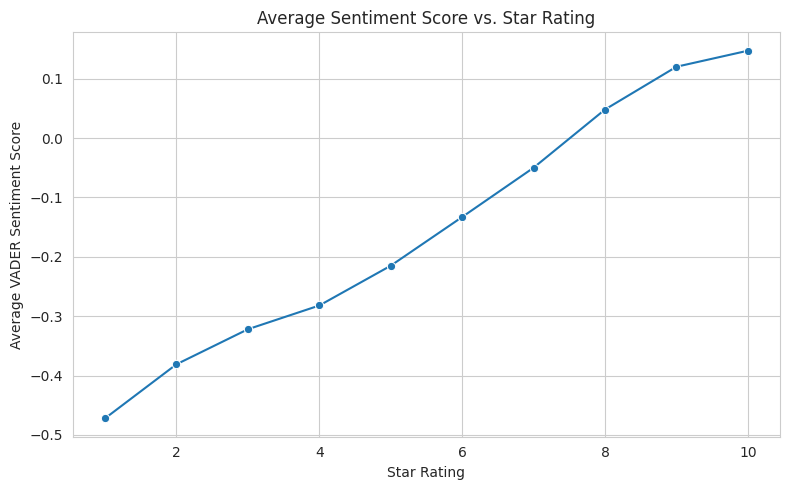

,rating,avg_sentiment
0,1,-0.472
1,2,-0.381
2,3,-0.322
3,4,-0.282
4,5,-0.215
5,6,-0.133
6,7,-0.050
7,8,0.048
8,9,0.120
9,10,0.147


In [16]:
# Q3: Does sentiment score actually correlate with the star rating?
# (Validates the NLP pipeline the same way the original sentiment project did.)

query_3 = """
SELECT rating, ROUND(AVG(sentiment_score), 3) AS avg_sentiment
FROM fact_reviews
GROUP BY rating
ORDER BY rating;
"""

rating_vs_sentiment = pd.read_sql_query(query_3, conn)

plt.figure(figsize=(8, 5))
sns.lineplot(data=rating_vs_sentiment, x='rating', y='avg_sentiment', marker='o')
plt.title('Average Sentiment Score vs. Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Sentiment Score')
plt.tight_layout()
plt.show()

rating_vs_sentiment


In [17]:
# Close the database connection cleanly
conn.close()
print("Connection closed. Pipeline complete — raw CSV -> cleaned & modeled tables -> SQLite warehouse -> SQL insights.")


Connection closed. Pipeline complete — raw CSV -> cleaned & modeled tables -> SQLite warehouse -> SQL insights.


## 7. Conclusion

This notebook demonstrates a small end-to-end **ETL pipeline**:

- **Extract:** Simulated two independent raw sources from a single dataset (drug master vs. review
  transactions).
- **Transform:** Cleaned text, standardized drug names, engineered sentiment/length/usefulness
  features, and modeled the data into a **star schema** (`dim_drug` + `fact_reviews`).
- **Load:** Persisted the modeled tables into a **SQLite data warehouse**.
- **Analyze:** Answered real questions (hidden side-effect burden by condition, review-volume
  leaders, sentiment-rating validation) using **SQL**, not just pandas filtering.

### Possible Extensions
- Swap SQLite for a cloud warehouse (Snowflake / BigQuery) to scale the same schema.
- Add a `dim_date` table for proper time-based analysis (month-over-month sentiment trends).
- Automate this as a scheduled pipeline (e.g. Airflow) if new review data arrives incrementally.

**Author:** Aritra Pal
